
# TF11-A2

A2 keeps the rigid four-vehicle payload setup, and adds a more paper-like control stack:

- hybrid model = nominal rigid-payload dynamics + lifted residual correction
- explicit Koopman model estimation (offline)
- online Koopman adaptation (windowed ridge update)
- self-triggered MPC update policy
- prescribed-time performance envelope
- two-stage tracking / recovery supervision
- stability-weight coordination with phase-plane analysis
- payload force evaluation

This notebook is intentionally independent from `tf11_A1_pre.ipynb`.


In [1]:

import importlib
import numpy as np
import matplotlib.pyplot as plt

import dynamics.cacalv3_payload_a2 as payload_a2
import tf11_a2_runtime as tf11_a2_runtime

importlib.reload(payload_a2)
importlib.reload(tf11_a2_runtime)

from tf11_a2_runtime import (
    default_a2_config,
    build_double_lane_change_reference_a2,
    generate_a2_dataset,
    fit_hybrid_residual_model_a2,
    run_tf11_a2_main,
    frenet_to_global_a2,
)

plt.style.use('dark_background')
np.set_printoptions(precision=4, suppress=True)


In [2]:

A2_CFG = default_a2_config()

# A practical default that is stable enough to reproduce the A2 idea end-to-end.
A2_CFG['dataset']['num_traj'] = 24
A2_CFG['dataset']['num_snaps'] = 220
A2_CFG['dataset']['save_tag'] = 'tf11_a2_notebook'
A2_CFG['mpc']['horizon'] = 12
A2_CFG['mpc']['extra_steps'] = 120
A2_CFG['vx_ref'] = 1.6
A2_CFG['koopman']['enable'] = True
A2_CFG['koopman']['blend_in_dynamics'] = 0.18
A2_CFG['online_adapt']['enable'] = True
A2_CFG['online_adapt']['update_every'] = 15
A2_CFG['online_adapt']['window'] = 60


A2_PATH = build_double_lane_change_reference_a2(
    path_length=A2_CFG['path_length'],
    num_points=A2_CFG['num_path_points'],
    amp_1=1.10,
    amp_2=-1.20,
    x1=18.0,
    x2=43.0,
    sigma_1=7.2,
    sigma_2=6.5,
)

print('A2_CFG vx_ref =', A2_CFG['vx_ref'])
print('dataset =', A2_CFG['dataset'])
print('mpc horizon =', A2_CFG['mpc']['horizon'])
print('koopman =', A2_CFG['koopman'])
print('online_adapt =', A2_CFG['online_adapt'])


A2_CFG vx_ref = 1.6
dataset = {'num_traj': 24, 'num_snaps': 220, 'sensor_noise': False, 'SNR_DB': 30, 'subset_weights': {1: 0.35, 2: 0.3, 3: 0.2, 4: 0.15}, 'save_tag': 'tf11_a2_notebook'}
mpc horizon = 12
koopman = {'enable': True, 'ridge': 0.0012, 'clip': array([1.8 , 0.55, 0.2 , 1.6 , 0.8 , 0.55]), 'blend_in_dynamics': 0.18}
online_adapt = {'enable': True, 'warmup_steps': 120, 'window': 60, 'update_every': 15, 'ridge': 0.002, 'blend': 0.05, 'max_delta_norm': 0.35, 'max_delta_abs': 0.08, 'accept_rmse_ratio': 1.03}



## Dataset + Hybrid Fit

The A2 dataset is generated at the **team rigid-body level**, not by stacking four corner trajectories as independent systems.
This is the key structural change compared with A1.


In [3]:

a2_dataset = generate_a2_dataset(payload_a2, A2_CFG, save=True)
a2_model = fit_hybrid_residual_model_a2(payload_a2, a2_dataset, A2_CFG)

print('train_rmse =', a2_model['train_rmse'])
print('val_rmse   =', a2_model['val_rmse'])
print('disturbance_bound =', np.round(a2_model['disturbance_bound'], 5))
print('variation_summary =', a2_dataset['variation_summary'])

if a2_model.get('koopman_model', None) is not None:
    print('koopman_train_rmse =', a2_model['koopman_model']['train_rmse'])
    print('koopman_val_rmse   =', a2_model['koopman_model']['val_rmse'])
    print('koopman_train_nrmse =', a2_model['koopman_model']['train_nrmse'])
    print('koopman_val_nrmse   =', a2_model['koopman_model']['val_nrmse'])


train_rmse = 0.0009697814381321601
val_rmse   = 1.5234767037085228
disturbance_bound = [0.0341 0.25   0.08   0.1906 0.35   0.15  ]
variation_summary = {'veh_1': 1, 'veh_1_2': 2, 'veh_1_2_3': 2, 'veh_1_2_4': 3, 'veh_1_3_4': 1, 'veh_1_4': 3, 'veh_2': 2, 'veh_2_4': 1, 'veh_3_4': 6, 'veh_4': 3}
koopman_train_rmse = 0.0028083272861916357
koopman_val_rmse   = 10.019785929218067
koopman_train_nrmse = 0.31645171515396403
koopman_val_nrmse   = 1377.0504865752555



## Main A2 Case

`change_mask=(0,1,2,3)` means all four corner vehicles have parameter variation effects coupled into the rigid payload system.


In [4]:

a2_result = run_tf11_a2_main(
    payload_a2,
    A2_CFG,
    a2_model,
    path_data=A2_PATH,
    change_mask=(0, 1, 2, 3),
    verbose=True,
)

a2_metrics = a2_result['metrics']
a2_metrics


[A2] train_rmse: 0.0009697814381321601 val_rmse: 1.5234767037085228
[A2] disturbance bound: [0.0341 0.25   0.08   0.1906 0.35   0.15  ]
[A2] koopman rmse train/val: 0.0028083272861916357 10.019785929218067
[A2] koopman nrmse train/val: 0.31645171515396403 1377.0504865752555
[A2] online koopman updates: 33 mean_delta_norm: 0.04494128642818622 skip: 0
[A2] metrics: {'rmse_e_y': 0.028198735034997736, 'rmse_e_psi': 0.030404406905518277, 'rmse_e_vx': 0.3440151498894215, 'max_abs_beta': 0.06802260638444728, 'max_abs_r': 0.043736045255646984, 'final_s': 59.70861796582304, 'target_s': 60.206270764101106, 'completion_ratio': 0.9917342032322852, 'solve_ratio': 0.36661211129296234, 'num_steps': 611, 'koopman_train_rmse': 0.0028083272861916357, 'koopman_val_rmse': 10.019785929218067, 'koopman_train_nrmse': 0.31645171515396403, 'koopman_val_nrmse': 1377.0504865752555, 'koopman_update_count': 33, 'koopman_skip_count': 0, 'koopman_delta_norm_mean': 0.04494128642818622, 'fx_peak_abs': 1412.83344346198

{'rmse_e_y': 0.028198735034997736,
 'rmse_e_psi': 0.030404406905518277,
 'rmse_e_vx': 0.3440151498894215,
 'max_abs_beta': 0.06802260638444728,
 'max_abs_r': 0.043736045255646984,
 'final_s': 59.70861796582304,
 'target_s': 60.206270764101106,
 'completion_ratio': 0.9917342032322852,
 'solve_ratio': 0.36661211129296234,
 'num_steps': 611,
 'koopman_train_rmse': 0.0028083272861916357,
 'koopman_val_rmse': 10.019785929218067,
 'koopman_train_nrmse': 0.31645171515396403,
 'koopman_val_nrmse': 1377.0504865752555,
 'koopman_update_count': 33,
 'koopman_skip_count': 0,
 'koopman_delta_norm_mean': 0.04494128642818622,
 'fx_peak_abs': 1412.833443461987,
 'fy_peak_abs': 703.3852875958755,
 'mz_peak_abs': 539.2318823198124,
 'corner_load_min': 4636.767382227459,
 'corner_load_max': 5173.232617772541}

In [5]:

print('=== A2 Summary ===')
for k, v in a2_metrics.items():
    print(f'{k}: {v}')

print('online_koopman_enabled =', a2_result['online_koopman_enabled'])
print('koopman_update_count =', len(a2_result['koopman_update_steps']))
if len(a2_result['koopman_delta_norm_hist']) > 0:
    print('koopman_delta_norm_mean =', float(np.mean(a2_result['koopman_delta_norm_hist'])))


=== A2 Summary ===
rmse_e_y: 0.028198735034997736
rmse_e_psi: 0.030404406905518277
rmse_e_vx: 0.3440151498894215
max_abs_beta: 0.06802260638444728
max_abs_r: 0.043736045255646984
final_s: 59.70861796582304
target_s: 60.206270764101106
completion_ratio: 0.9917342032322852
solve_ratio: 0.36661211129296234
num_steps: 611
koopman_train_rmse: 0.0028083272861916357
koopman_val_rmse: 10.019785929218067
koopman_train_nrmse: 0.31645171515396403
koopman_val_nrmse: 1377.0504865752555
koopman_update_count: 33
koopman_skip_count: 0
koopman_delta_norm_mean: 0.04494128642818622
fx_peak_abs: 1412.833443461987
fy_peak_abs: 703.3852875958755
mz_peak_abs: 539.2318823198124
corner_load_min: 4636.767382227459
corner_load_max: 5173.232617772541
online_koopman_enabled = True
koopman_update_count = 33
koopman_delta_norm_mean = 0.04494128642818622


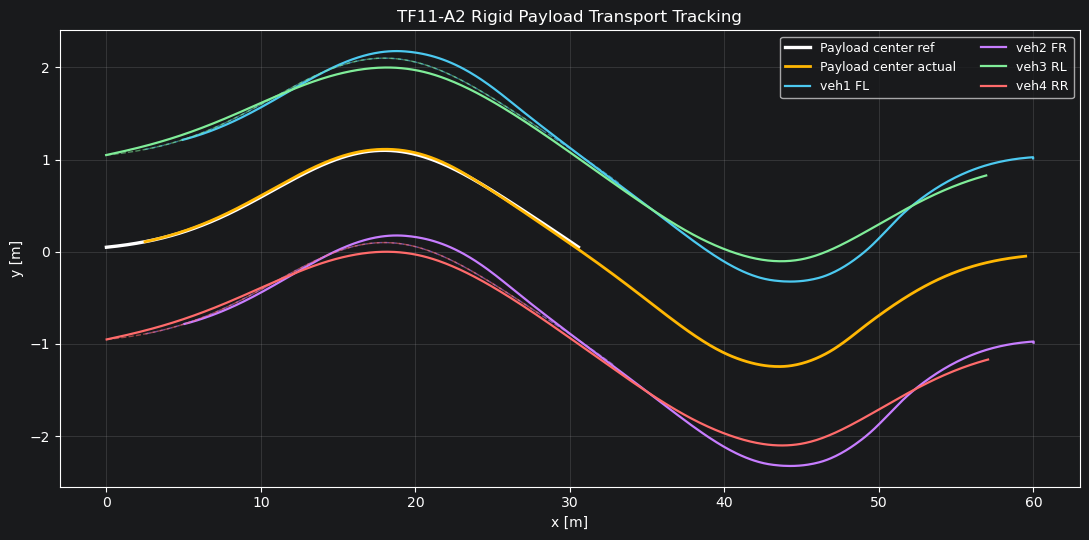

In [6]:

team_hist = a2_result['team_state_hist']
team_ref = a2_result['team_ref_hist']
corner_histories = a2_result['corner_state_histories']
corner_ref_histories = a2_result['corner_ref_histories']

x_team_g, y_team_g = frenet_to_global_a2(team_hist[:, 0], team_hist[:, 1], A2_PATH)
x_ref_g, y_ref_g = frenet_to_global_a2(team_ref[:, 0], team_ref[:, 1], A2_PATH)

fig, ax = plt.subplots(1, 1, figsize=(11, 5.5))
ax.plot(x_ref_g, y_ref_g, color='white', linewidth=2.4, label='Payload center ref')
ax.plot(x_team_g, y_team_g, color='#ffb703', linewidth=2.0, label='Payload center actual')

colors = ['#4cc9f0', '#c77dff', '#80ed99', '#ff6b6b']
labels = ['veh1 FL', 'veh2 FR', 'veh3 RL', 'veh4 RR']
for i, (xh, rh) in enumerate(zip(corner_histories, corner_ref_histories)):
    xg, yg = frenet_to_global_a2(xh[:, 0], xh[:, 1], A2_PATH)
    xgr, ygr = frenet_to_global_a2(rh[:, 0], rh[:, 1], A2_PATH)
    ax.plot(xgr, ygr, color=colors[i], linestyle='--', linewidth=1.0, alpha=0.55)
    ax.plot(xg, yg, color=colors[i], linewidth=1.6, label=labels[i])

ax.set_title('TF11-A2 Rigid Payload Transport Tracking')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


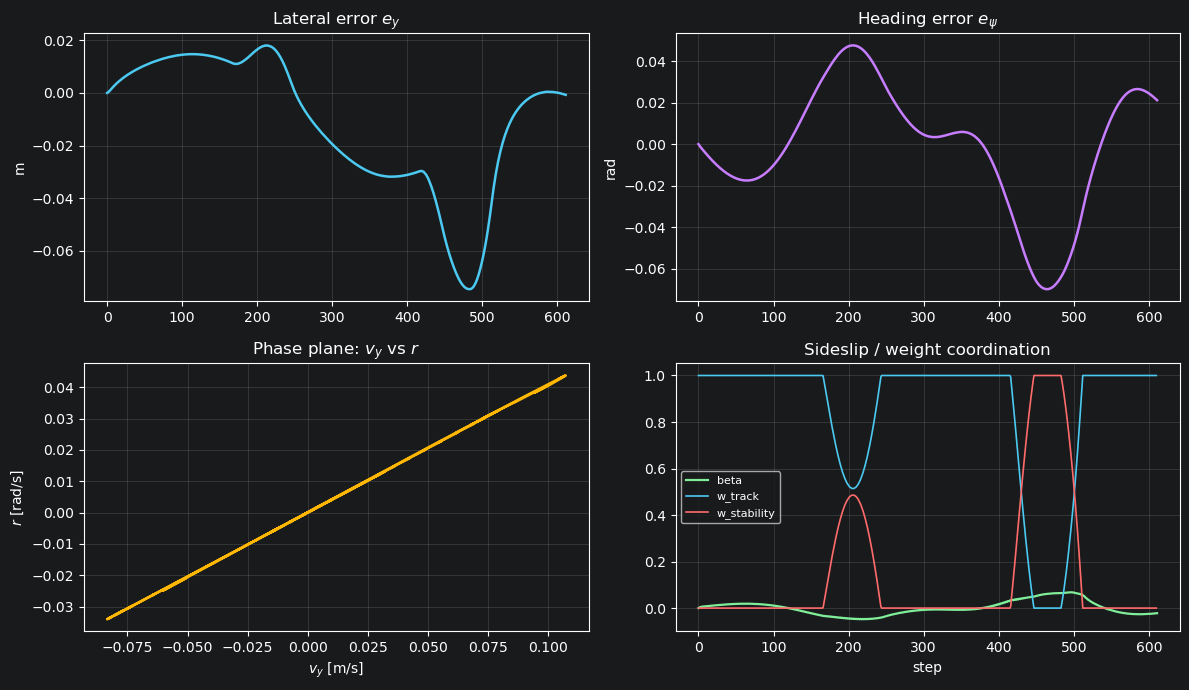

In [7]:

team_err = a2_result['team_error_hist']
phase_plane = a2_result['phase_plane']
beta_hist = a2_result['beta_hist']
weight_hist = a2_result['weight_hist']

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
axes[0, 0].plot(team_err['e_y'], color='#4cc9f0', linewidth=1.8)
axes[0, 0].set_title('Lateral error $e_y$')
axes[0, 0].set_ylabel('m')
axes[0, 0].grid(True, alpha=0.25)

axes[0, 1].plot(team_err['e_psi'], color='#c77dff', linewidth=1.8)
axes[0, 1].set_title('Heading error $e_\psi$')
axes[0, 1].set_ylabel('rad')
axes[0, 1].grid(True, alpha=0.25)

axes[1, 0].plot(phase_plane[:, 0], phase_plane[:, 1], color='#ffb703', linewidth=1.8)
axes[1, 0].set_title('Phase plane: $v_y$ vs $r$')
axes[1, 0].set_xlabel('$v_y$ [m/s]')
axes[1, 0].set_ylabel('$r$ [rad/s]')
axes[1, 0].grid(True, alpha=0.25)

axes[1, 1].plot(beta_hist, color='#80ed99', linewidth=1.6, label='beta')
if len(weight_hist) > 0:
    axes[1, 1].plot(weight_hist[:, 0], color='#4cc9f0', linewidth=1.2, label='w_track')
    axes[1, 1].plot(weight_hist[:, 1], color='#ff6b6b', linewidth=1.2, label='w_stability')
axes[1, 1].set_title('Sideslip / weight coordination')
axes[1, 1].set_xlabel('step')
axes[1, 1].grid(True, alpha=0.25)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()


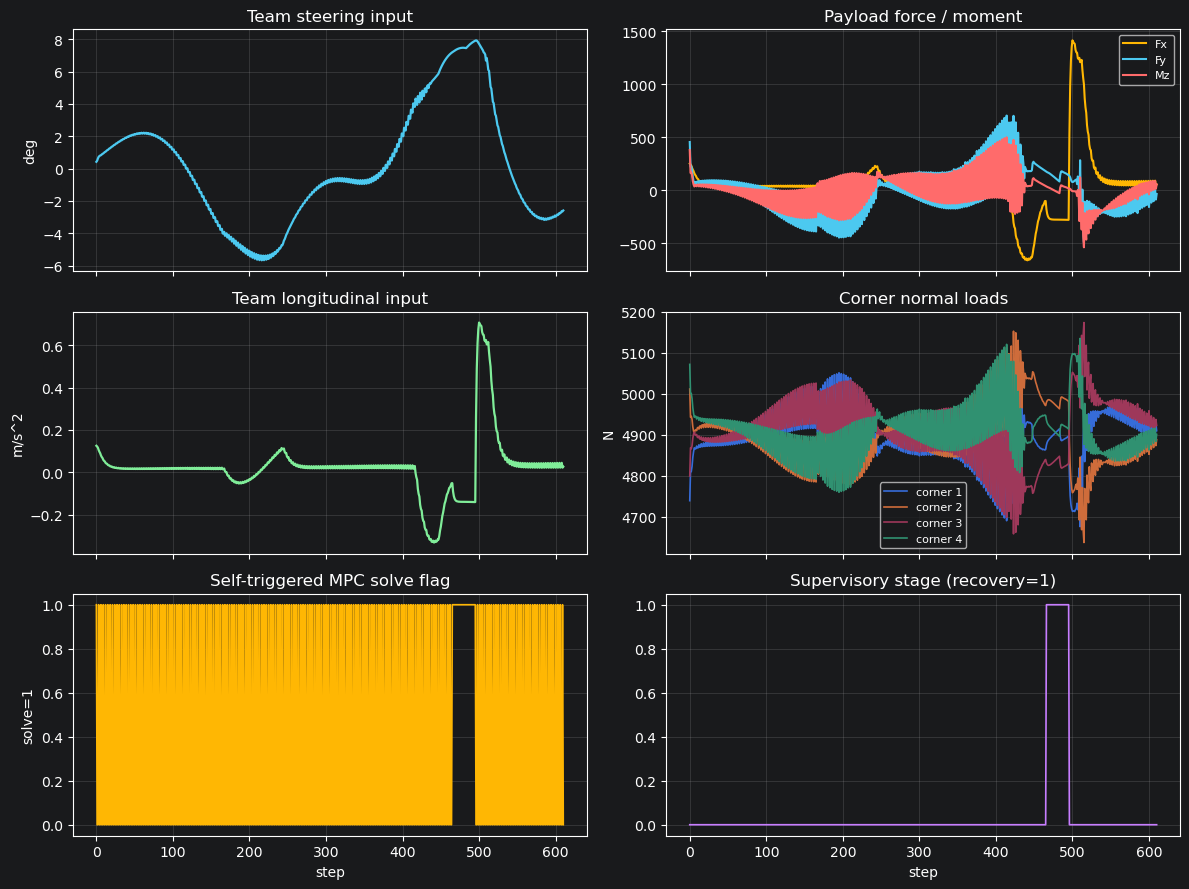

In [8]:

u_hist = a2_result['team_input_hist']
force_hist = a2_result['payload_force_hist']
solve_flags = np.asarray(a2_result['solve_flags'], dtype=float)
stage_hist = a2_result['stage_hist']

fx = np.array([item['fx_payload'] for item in force_hist], dtype=float)
fy = np.array([item['fy_payload'] for item in force_hist], dtype=float)
mz = np.array([item['mz_payload'] for item in force_hist], dtype=float)
loads = np.array([item['corner_normal_loads'] for item in force_hist], dtype=float)

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex='col')
axes[0, 0].plot(np.rad2deg(u_hist[:, 0]), color='#4cc9f0', linewidth=1.6)
axes[0, 0].set_title('Team steering input')
axes[0, 0].set_ylabel('deg')
axes[0, 0].grid(True, alpha=0.25)

axes[1, 0].plot(u_hist[:, 1], color='#80ed99', linewidth=1.6)
axes[1, 0].set_title('Team longitudinal input')
axes[1, 0].set_ylabel('m/s^2')
axes[1, 0].grid(True, alpha=0.25)

axes[2, 0].plot(solve_flags, color='#ffb703', linewidth=1.2)
axes[2, 0].set_title('Self-triggered MPC solve flag')
axes[2, 0].set_xlabel('step')
axes[2, 0].set_ylabel('solve=1')
axes[2, 0].grid(True, alpha=0.25)

axes[0, 1].plot(fx, color='#ffb703', linewidth=1.5, label='Fx')
axes[0, 1].plot(fy, color='#4cc9f0', linewidth=1.5, label='Fy')
axes[0, 1].plot(mz, color='#ff6b6b', linewidth=1.5, label='Mz')
axes[0, 1].set_title('Payload force / moment')
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].legend(fontsize=8)

for i in range(loads.shape[1]):
    axes[1, 1].plot(loads[:, i], linewidth=1.2, label=f'corner {i+1}')
axes[1, 1].set_title('Corner normal loads')
axes[1, 1].set_ylabel('N')
axes[1, 1].grid(True, alpha=0.25)
axes[1, 1].legend(fontsize=8)

stage_num = np.array([1 if s == 'recovery' else 0 for s in stage_hist], dtype=float)
axes[2, 1].plot(stage_num, color='#c77dff', linewidth=1.2)
axes[2, 1].set_title('Supervisory stage (recovery=1)')
axes[2, 1].set_xlabel('step')
axes[2, 1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
